In [5]:
import json
import random as rnd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyomo.environ import *
from bluebikes_rebalancing.config import LOCAL_DATA_DIR
from bluebikes_rebalancing.plots import COLORS
from bluebikes_rebalancing.model import build_vrp_model

# --- Parameters ---
Q = 20
B = 2
ALPHA = 1.0
SERVICE_TIME = 7.0
TIME_PER_BIKE = 1.5
T_MAX = 180.0

BETA_VALUES = [1.0, 10.0, 25.0, 37.5, 50.0, 62.5, 75.0, 100.0, 150.0]
DATES = ["20260306"] # ["20260302", "20260303", "20260304", "20260305", "20260306"]
depot_names = ["depot_start", "depot_end"]

# --- Directories ---
stations_dir = LOCAL_DATA_DIR / "processed" / "stations"
initial_status_dir = LOCAL_DATA_DIR / "processed" / "initial_status"
demand_dir = LOCAL_DATA_DIR / "processed" / "demand"
network_dir = LOCAL_DATA_DIR / "processed" / "network"

# --- Date-independent data ---
stations_df = pd.read_csv(stations_dir / "station_information.csv", index_col="idx")

network_df = pd.read_csv(network_dir / "dist_ttime_long.csv")
network_df["ttime_min"] = network_df["ttime_s"] / 60
idx_to_name = stations_df["short_name"].to_dict()
network_df["origin"] = network_df["origin_idx"].map(idx_to_name)
network_df["dest"] = network_df["dest_idx"].map(idx_to_name)

In [6]:
from tqdm.notebook import tqdm
from bluebikes_rebalancing.model import build_vrp_model

# --- Results storage ---
results = {
    "date": [],
    "beta": [],
    "total_distance_m": [],
    "total_deviation_sq": [],
    "mean_abs_deviation": [],
    "status": [],
}

# --- Parametric sweep ---
total_solves = len(DATES) * len(BETA_VALUES)
with tqdm(total=total_solves, desc="Parametric sweep") as pbar:
    for date in DATES:
        print(f"\nDate {date} — loading data...")

        initial_status_df = pd.read_csv(
            initial_status_dir / f"initial_status_{date}.csv", index_col="idx"
        )
        demand_df = pd.read_csv(demand_dir / f"demand_{date}.csv", index_col="idx")

        active_stations = initial_status_df["short_name"].tolist()
        active_stations_with_depots = active_stations + depot_names

        sdf = stations_df[stations_df["short_name"].isin(active_stations_with_depots)].copy()
        ddf = demand_df[demand_df["station_id"].isin(active_stations)].copy()
        idf = initial_status_df[initial_status_df["short_name"].isin(active_stations)].copy()
        ndf = network_df[
            network_df["origin"].isin(active_stations_with_depots)
            & network_df["dest"].isin(active_stations_with_depots)
        ].copy()

        nodes = sdf["short_name"].tolist()
        stations = [n for n in nodes if n not in depot_names]

        b = idf.set_index("short_name")["initial_status"].to_dict()
        b["depot_start"] = Q
        b["depot_end"] = 0

        c = sdf.set_index("short_name")["capacity"].to_dict()
        c["depot_start"] = Q
        c["depot_end"] = Q

        ddf["d"] = ddf["dropoffs_forecast"] - ddf["pickups_forecast"]
        d = ddf.set_index("station_id")["d"].to_dict()
        t = {i: c[i] / 2 - d[i] for i in stations}

        dist = {(row.origin, row.dest): row.dist_m for row in ndf.itertuples()}
        ttime = {(row.origin, row.dest): row.ttime_min for row in ndf.itertuples()}

        print(f"  {len(stations)} active stations, {len(dist)} arcs")

        for beta in BETA_VALUES:
            pbar.set_description(f"date={date}, beta={beta}")

            model = build_vrp_model(
                nodes=nodes,
                stations=stations,
                b=b,
                c=c,
                t=t,
                dist=dist,
                ttime=ttime,
                Q=Q,
                B=B,
                T_MAX=T_MAX,
                ALPHA=ALPHA,
                BETA=beta,
                SERVICE_TIME=SERVICE_TIME,
                TIME_PER_BIKE=TIME_PER_BIKE,
            )

            solver = SolverFactory("gurobi")
            solver.options["TimeLimit"] = 300
            solver.options["MIPGap"] = 0.05
            solver.options["Threads"] = 4
            result = solver.solve(model, tee=False)

            status = str(result.solver.termination_condition)
            total_distance_m = sum(
                value(model.dist[i, j]) * value(model.x[i, j]) for (i, j) in model.ARCS
            )
            deviations = [value(model.b_final[i]) - value(model.t[i]) for i in stations]
            total_deviation_sq = sum(dev**2 for dev in deviations)
            mean_abs_deviation = sum(abs(dev) for dev in deviations) / len(deviations)

            results["date"].append(date)
            results["beta"].append(beta)
            results["total_distance_m"].append(total_distance_m)
            results["total_deviation_sq"].append(total_deviation_sq)
            results["mean_abs_deviation"].append(mean_abs_deviation)
            results["status"].append(status)

            pbar.set_postfix(
                {
                    "status": status,
                    "dist": f"{total_distance_m:.0f}m",
                    "total_deviation_sq": f"{total_deviation_sq:.2f}",
                }
            )
            pbar.update(1)

results_df = pd.DataFrame(results)
print(f"\nDone. {len(results_df)} solves recorded.")

Parametric sweep:   0%|          | 0/9 [00:00<?, ?it/s]


Date 20260306 — loading data...
  44 active stations, 2070 arcs

Done. 9 solves recorded.


In [ ]:
results_dir = LOCAL_DATA_DIR / "rebalancing_results" / "parametric_analysis"
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(results_dir / f"{DATES[0]}.csv", index=False)

In [8]:
results_df

,date,beta,total_distance_m,total_deviation_sq,mean_abs_deviation,status
0,20260306,1.0,5555.368168,1364.5,3.931818,optimal
1,20260306,10.0,7650.896754,924.5,3.272727,optimal
2,20260306,25.0,10076.757826,795.5,3.363636,optimal
3,20260306,37.5,10174.445108,801.5,3.318182,optimal
4,20260306,50.0,10076.757826,795.5,3.363636,optimal
5,20260306,62.5,10174.445108,792.5,3.272727,optimal
6,20260306,75.0,10296.413569,790.5,3.363636,optimal
7,20260306,100.0,10174.445108,792.5,3.272727,optimal
8,20260306,150.0,10296.413569,790.5,3.363636,optimal


---

Load results dataframes to analyze them

In [52]:
DATES = ["20260302", "20260303", "20260304", "20260305", "20260306"]

results_dir = LOCAL_DATA_DIR / "rebalancing_results" / "parametric_analysis"

results_df = pd.concat(
    [pd.read_csv(results_dir / f"{date}.csv") for date in DATES],
    ignore_index=True
)

results_df["date"] = results_df["date"].astype(str)
results_df = results_df.drop(columns="Unnamed: 0")

In [56]:
filt = results_df["beta"] < 30
print(results_df.loc[filt, :].to_string())

        date  beta  total_distance_m  total_deviation_sq  mean_abs_deviation        status
0   20260302   1.0       6983.855984             1074.50            4.159091       optimal
1   20260302  10.0       6983.855984             1074.50            4.159091       optimal
2   20260302  25.0       6983.855984             1074.50            4.159091       optimal
9   20260303   1.0       9566.362955             1375.25            4.593023       optimal
10  20260303  10.0       9913.904255             1133.25            4.244186       optimal
11  20260303  25.0       9913.904255             1133.25            4.244186       optimal
18  20260304   1.0       6003.221860             1813.00            5.166667       optimal
19  20260304  10.0       8192.337999             1226.00            4.404762  maxTimeLimit
20  20260304  25.0       9050.824187             1183.00            4.428571  maxTimeLimit
27  20260305   1.0       4726.921419             1125.50            4.068182  maxTimeLimit

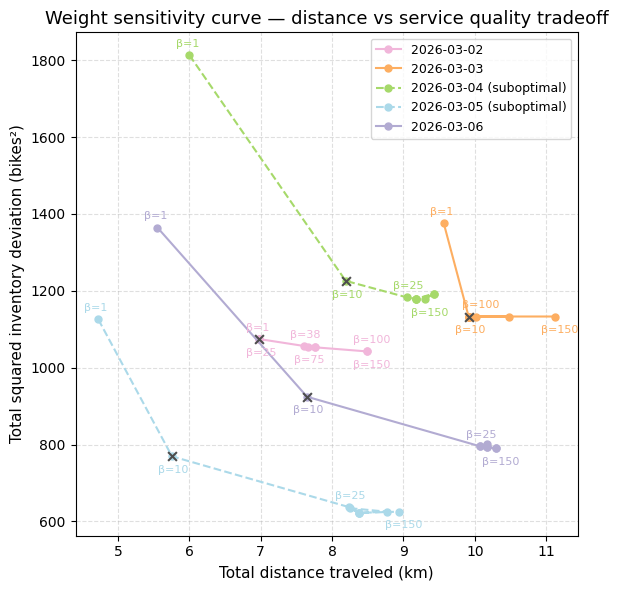

In [71]:
def select_annotation_points(group):
    pts = group.sort_values("beta").copy()
    pts["x"] = pts["total_distance_m"] / 1000
    pts["y"] = pts["total_deviation_sq"]

    # Normalize for fair distance comparison
    x_range = pts["x"].max() - pts["x"].min() + 1e-9
    y_range = pts["y"].max() - pts["y"].min() + 1e-9
    pts["x_n"] = (pts["x"] - pts["x"].min()) / x_range
    pts["y_n"] = (pts["y"] - pts["y"].min()) / y_range

    # Consecutive distances between sorted beta points
    pts["dist"] = ((pts["x_n"].diff() ** 2 + pts["y_n"].diff() ** 2) ** 0.5).fillna(0)

    # Pick the 2 largest jumps and take both endpoints of each
    top2 = pts.nlargest(2, "dist")
    jump_indices = set()
    for idx in top2.index:
        pos = pts.index.get_loc(idx)
        jump_indices.add(pts.index[pos - 1])  # start of jump
        jump_indices.add(idx)  # end of jump

    # Always include extremes
    extremes = {pts.index[0], pts.index[-1]}
    selected_idx = sorted(jump_indices | extremes)

    return pts.loc[selected_idx]


fig, ax = plt.subplots(figsize=(6, 6))

date_colors = {
    "20260302": COLORS[0],
    "20260303": COLORS[2],
    "20260304": COLORS[4],
    "20260305": COLORS[6],
    "20260306": COLORS[8],
}

date_styles = {
    "20260302": "-",
    "20260303": "-",
    "20260304": "--",
    "20260305": "--",
    "20260306": "-",
}

annotate_betas = [1.0, 10, 25, 150]

for date, group in results_df.groupby("date"):
    group = group.sort_values("beta")
    color = date_colors[date]
    ls = date_styles[date]

    ax.plot(
        group["total_distance_m"] / 1000,
        group["total_deviation_sq"],
        color=color,
        linestyle=ls,
        linewidth=1.5,
        marker="o",
        markersize=5,
        label=f"{date[:4]}-{date[4:6]}-{date[6:]} {'(suboptimal)' if ls == '--' else ''}",
    )

    # Highlight beta=10 with an outer ring
    beta10 = group[group["beta"] == 10.0]
    if len(beta10) > 0:
        ax.scatter(
            beta10["total_distance_m"] / 1000,
            beta10["total_deviation_sq"],
            s=40,
            marker="x",
            color=COLORS[-1],
            linewidth=1.5,
            zorder=5,
        )

    # Annotate selected beta values on the first optimal date only
    offsets = [(-10, 6), (-10, -12)]

    for k, (_, pt) in enumerate(select_annotation_points(group).iterrows()):
        ax.annotate(
            f"β={pt['beta']:.0f}",
            xy=(pt["x"], pt["y"]),
            xytext=offsets[k % 2],
            textcoords="offset points",
            fontsize=8,
            color=color,
        )

ax.set_xlabel("Total distance traveled (km)", fontsize=11)
ax.set_ylabel("Total squared inventory deviation (bikes²)", fontsize=11)
ax.set_title("Weight sensitivity curve — distance vs service quality tradeoff", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()